In [1]:
import os
import shutil
import torch
from sklearn.model_selection import train_test_split

# Kiểm tra xem Kaggle đã kích hoạt GPU chưa
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device.upper()}")
if device == "cuda":
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

Đang sử dụng thiết bị: CUDA
Tên GPU: Tesla T4


In [5]:
# Cập nhật đường dẫn tuyệt đối chính xác theo hệ thống Kaggle của bạn
data_source_dir = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
classes = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]

# Thư mục đích có quyền ghi trên Kaggle
output_base_dir = "/kaggle/working/covid_dataset"

print("--- Đang tiến hành phân chia dữ liệu (80% Train / 20% Val) ---")

for cls in classes:
    # Truy cập thẳng vào thư mục images bên trong mỗi nhãn bệnh
    cls_dir = os.path.join(data_source_dir, cls, "images")
    
    if os.path.exists(cls_dir):
        images = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    else:
        print(f"Lỗi: Không tìm thấy thư mục {cls_dir}")
        continue
        
    if len(images) == 0:
        print(f"Cảnh báo: Không tìm thấy ảnh nào trong {cls_dir}.")
        continue
        
    print(f"-> Tìm thấy {len(images)} ảnh cho nhãn [{cls}]. Đang phân chia...")
        
    # Chia tách file ngẫu nhiên 80/20
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
    
    # Tạo cấu trúc thư mục chuẩn YOLO-cls (Đổi dấu cách thành dấu gạch dưới)
    cls_folder_name = cls.replace(" ", "_")
    os.makedirs(os.path.join(output_base_dir, "train", cls_folder_name), exist_ok=True)
    os.makedirs(os.path.join(output_base_dir, "val", cls_folder_name), exist_ok=True)
    
    # Copy ảnh vào tập Train
    for img in train_imgs:
        shutil.copy(os.path.join(cls_dir, img), os.path.join(output_base_dir, "train", cls_folder_name, img))
        
    # Copy ảnh vào tập Val
    for img in val_imgs:
        shutil.copy(os.path.join(cls_dir, img), os.path.join(output_base_dir, "val", cls_folder_name, img))

print("\n--- Chuẩn bị dữ liệu hoàn tất! ---")
print("Cấu trúc thư mục train hiện tại gồm có:")
!ls /kaggle/working/covid_dataset/train

--- Đang tiến hành phân chia dữ liệu (80% Train / 20% Val) ---
-> Tìm thấy 3616 ảnh cho nhãn [COVID]. Đang phân chia...
-> Tìm thấy 6012 ảnh cho nhãn [Lung_Opacity]. Đang phân chia...
-> Tìm thấy 10192 ảnh cho nhãn [Normal]. Đang phân chia...
-> Tìm thấy 1345 ảnh cho nhãn [Viral Pneumonia]. Đang phân chia...

--- Chuẩn bị dữ liệu hoàn tất! ---
Cấu trúc thư mục train hiện tại gồm có:
COVID  Lung_Opacity  Normal  Viral_Pneumonia


In [6]:
# Cài đặt âm thầm (quiet) để tránh hiển thị log quá dài
!pip install ultralytics -q

# Khai báo thư viện sau khi cài đặt thành công
from ultralytics import YOLO
print("Đã cài đặt YOLOv8 thành công!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.1 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Đã cài đặt YOLOv8 thành công!


In [7]:
# Tải mô hình cấu trúc phân loại (classification) bản nano
model = YOLO("yolov8n-cls.pt")

# Kích hoạt quá trình huấn luyện
results = model.train(
    data=output_base_dir, 
    epochs=15,            # Thử nghiệm trước với 15 epochs (Kaggle chạy mất khoảng 5-10 phút)
    imgsz=256,            # Resize ảnh về kích thước 256x256 để tối ưu tốc độ xử lý
    batch=64,             # Batch size 64 tận dụng tốt VRAM của GPU T4
    device=0              # Chỉ định ép buộc chạy trên GPU số 0
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/covid_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [8]:
# Đánh giá lại mô hình trên tập validation
metrics = model.val()

print("\n" + "="*30)
print(f"ĐỘ CHÍNH XÁC TOP-1 ACCURACY: {metrics.top1 * 100:.2f}%")
print(f"ĐỘ CHÍNH XÁC TOP-5 ACCURACY: {metrics.top5 * 100:.2f}%")
print("="*30)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/covid_dataset/train... found 16930 images in 4 classes ✅ 
val: /kaggle/working/covid_dataset/val... found 4235 images in 4 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1031.1±435.1 MB/s, size: 34.9 KB)
val: Scanning /kaggle/working/covid_dataset/val... 4235 images, 0 corrupt: 100% ━━━━━━━━━━━━ 4235/4235 1.6Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 265/265 23.9it/s 11.1s<0.0s
                   all       0.95          1
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

ĐỘ CHÍNH XÁC TOP-1 ACCURACY: 94.99%
ĐỘ CHÍNH XÁC TOP-5 ACCURACY: 100.00%



image 1/1 /kaggle/working/covid_dataset/val/COVID/COVID-2796.png: 256x256 COVID 0.99, Normal 0.01, Lung_Opacity 0.00, Viral_Pneumonia 0.00, 2.8ms
Speed: 4.8ms preprocess, 2.8ms inference, 0.1ms postprocess per image at shape (1, 3, 256, 256)


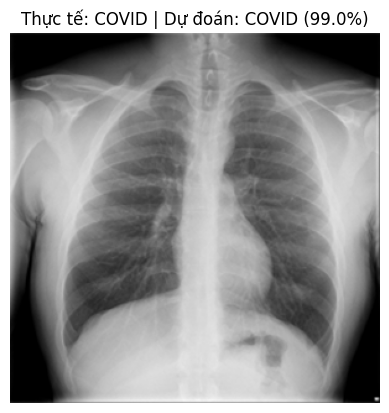

In [9]:
import cv2
import matplotlib.pyplot as plt

# Lấy thử 1 ảnh ngẫu nhiên trong tập val để test
test_class = "COVID"
test_dir = os.path.join(output_base_dir, "val", test_class)
sample_img = os.listdir(test_dir)[0]
test_image_path = os.path.join(test_dir, sample_img)

# Dự đoán bằng mô hình vừa train
pred_results = model.predict(source=test_image_path, save=False)

# Lấy ra nhãn có điểm tin cậy cao nhất
top1_idx = pred_results[0].probs.top1
predicted_label = pred_results[0].names[top1_idx]
conf_score = pred_results[0].probs.top1conf.item()

# Hiển thị ảnh kèm kết quả
img_rgb = cv2.imread(test_image_path)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb, cmap='gray')
plt.title(f"Thực tế: {test_class} | Dự đoán: {predicted_label} ({conf_score*100:.1f}%)")
plt.axis('off')
plt.show()

In [10]:
import shutil

# Đường dẫn tới thư mục kết quả train của bạn
dir_to_zip = '/kaggle/working/runs'

# Tên file zip bạn muốn tạo ra (sẽ lưu tại /kaggle/working/train_results.zip)
output_filename = '/kaggle/working/train_results'

# Tiến hành nén
shutil.make_archive(output_filename, 'zip', dir_to_zip)

print("--- Đã nén thành công toàn bộ thư mục 'runs' thành file train_results.zip! ---")

--- Đã nén thành công toàn bộ thư mục 'runs' thành file train_results.zip! ---
